# Extended Data Figure 12

In [14]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

purple_muted = '#8E8AB8'   # parental / wild-type
green_muted  = '#7FA77F'   # variant family
blue_pair    = '#5A8DC8'   # single / category A
gold_pair    = '#E8B85F'   # combination / category B
red_ctrl     = '#C86A6A'   # negative controls
gray_bg      = '#C8C8C8'   # background scatter

# sequential blues (panel i)
blues_5 = sns.color_palette('Blues', 6)[1:]   # skip lightest
# sequential greens (panel j)
greens_5 = sns.color_palette('Greens', 6)[1:]

# diverging (panel e)
diverging = sns.diverging_palette(230, 20, s=60, l=70, as_cmap=True)

In [15]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':         pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':         pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0':     {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC':     {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':      {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':      {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                       'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    # FSR screens — d15 cols are 'd15-1','d15-2','d15-3'
    'ABE_EPO_T0_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_T0_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_EPO_BC_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_BC_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_BC_T0_FSR':  {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_BC_T0_FSR':  {'bm':    ['bm2','bm3','bm4','bm5'],
                       'spleen':['spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')


Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides
  ABE_EPO_T0_FSR: 376 guides
  CBE_EPO_T0_FSR: 1257 guides
  ABE_EPO_BC_FSR: 376 guides
  CBE_EPO_BC_FSR: 1257 guides
  ABE_BC_T0_FSR: 376 guides
  CBE_BC_T0_FSR: 1257 guides


In [10]:
# load library

LIB = pd.read_csv(BASE + 'MBESv2_CORRECTED.csv')
LIB_FOCUSED = pd.read_csv(BASE + 'MBESv2_focused.csv')

ABE = LIB[LIB['Editor'] == 'ABE'].reset_index(drop=True)
ABE_FOCUSED = LIB_FOCUSED[LIB_FOCUSED['Editor'] == 'ABE'].reset_index(drop=True)

In [11]:
ABE['classification'].value_counts()

classification
targeting guide           1034
safe-targeting control      26
non-targeting control       10
Name: count, dtype: int64

In [12]:
n_controls = len(ABE[ABE['classification'].isin(['non-targeting control', 'safe-targeting control'])])
n_all= len(ABE)
print(f'Library: {n_controls/n_all*100:.1f}% (n= {n_controls}/{n_all}) non- and safe-targeting guides')

n_controls = len(ABE_FOCUSED[ABE_FOCUSED['classification'].isin(['non-targeting control', 'safe-targeting control'])])
n_all= len(ABE_FOCUSED)
print(f'Library Focused: {n_controls/n_all*100:.1f}% (n= {n_controls}/{n_all}) non- and safe-targeting guides')

Library: 3.4% (n= 36/1070) non- and safe-targeting guides
Library Focused: 54.8% (n= 206/376) non- and safe-targeting guides


## 12a

Scatter plots showing the correlation of guide-level median LFC z-scores between the original and focused ABE screens across three tissue contexts (D15 in vitro, Spleen, and Bone Marrow). Only guides present in both screens with target base editing ≥ 10% are shown. Blue dots, targeting guides; red dots, control guides (non-targeting and safe-targeting). $R_P$, Pearson correlation coefficient; $R_S$, Spearman correlation coefficient, computed separately for targeting guides (blue) and control guides (red).

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


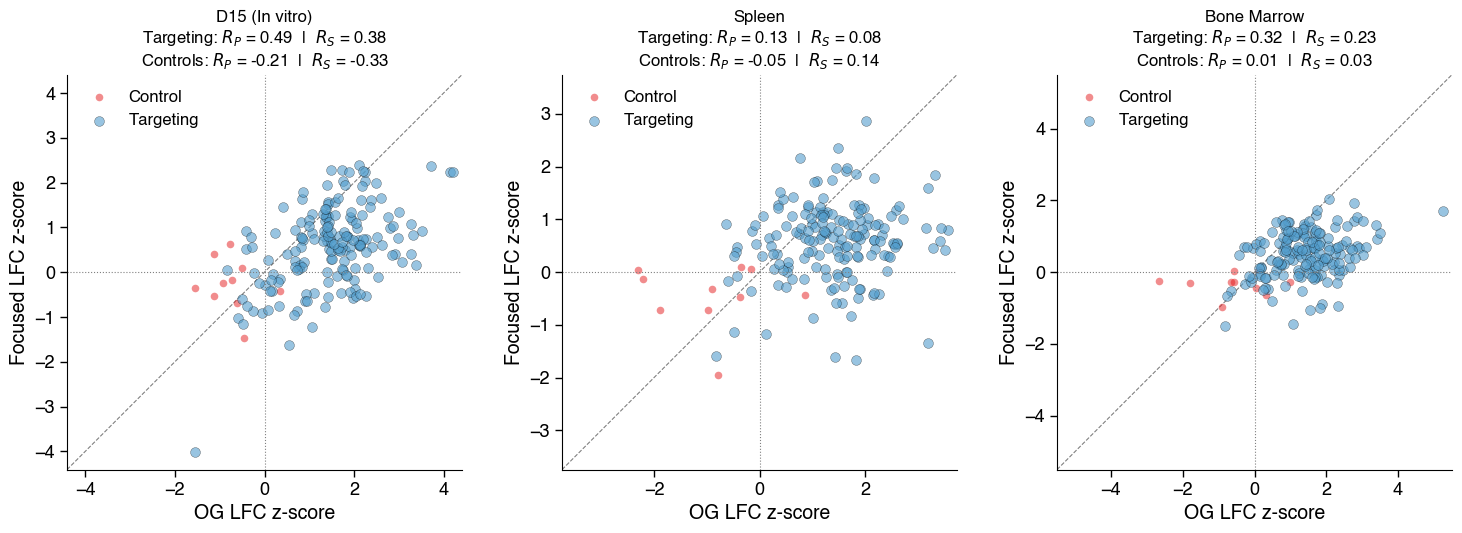

In [16]:
from scipy.stats import pearsonr, spearmanr

# ── Load data ─────────────────────────────────────────────────────────────────
ABE_OG  = dfs['ABE_OG']
ABE_EPO = dfs['ABE_EPO_T0']

min_edit           = 10
FDR_cutoff         = 0.1
min_sensor_og      = 10
min_sensor_focused = 100

cond_list   = ['d15', 'spleen', 'bm']
cond_labels = {'d15': 'D15 (In vitro)', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cond in zip(axes, cond_list):
    z_col      = f'z_score_median_{cond}'
    fdr_col    = f'FDR_{cond}_fishers'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    og_targ = ABE_OG[ABE_OG['classification'] == 'targeting guide'].copy()
    if sensor_col in og_targ.columns:
        og_targ = og_targ[og_targ[sensor_col] >= min_sensor_og]
    og_targ = og_targ[og_targ[edit_col] >= min_edit][['gRNA_id', z_col, fdr_col]].rename(
        columns={z_col: 'z_og', fdr_col: 'fdr_og'})

    epo_targ = ABE_EPO[ABE_EPO['classification'] == 'targeting guide'].copy()
    if sensor_col in epo_targ.columns:
        epo_targ = epo_targ[epo_targ[sensor_col] >= min_sensor_focused]
    epo_targ = epo_targ[epo_targ[edit_col] >= min_edit][['gRNA_id', z_col, fdr_col]].rename(
        columns={z_col: 'z_epo', fdr_col: 'fdr_epo'})

    merged = pd.merge(og_targ, epo_targ, on='gRNA_id').dropna(subset=['z_og', 'z_epo'])

    og_ctrl  = ABE_OG[ ABE_OG['classification'].isin(['non-targeting control','safe-targeting control'])][['gRNA_id', z_col]].rename(columns={z_col:'z_og'})
    epo_ctrl = ABE_EPO[ABE_EPO['classification'].isin(['non-targeting control','safe-targeting control'])][['gRNA_id', z_col]].rename(columns={z_col:'z_epo'})
    ctrl     = pd.merge(og_ctrl, epo_ctrl, on='gRNA_id').dropna()

    r_p, _ = pearsonr( merged['z_og'], merged['z_epo'])
    r_s, _ = spearmanr(merged['z_og'], merged['z_epo'])
    r_p_ctrl, _ = pearsonr( ctrl['z_og'], ctrl['z_epo'])
    r_s_ctrl, _ = spearmanr(ctrl['z_og'], ctrl['z_epo'])

    ax.scatter(ctrl['z_og'],   ctrl['z_epo'],
               color='#e41a1c', s=30, alpha=0.5, linewidths=0, label='Control')
    ax.scatter(merged['z_og'], merged['z_epo'],
               color=blues[3],  s=50, alpha=0.6, edgecolor='black', linewidths=0.3, label='Targeting')

    lim = max(abs(merged['z_og']).max(), abs(merged['z_epo']).max()) * 1.05
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.plot([-lim, lim], [-lim, lim], color='grey', linestyle='--', linewidth=0.8, zorder=0)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')

    ax.set_xlabel('OG LFC z-score', fontsize=14)
    ax.set_ylabel('Focused LFC z-score', fontsize=14)
    ax.set_title(
        f"{cond_labels[cond]}\n"
        f"Targeting: $R_P$ = {r_p:.2f}  |  $R_S$ = {r_s:.2f}\n"
        f"Controls: $R_P$ = {r_p_ctrl:.2f}  |  $R_S$ = {r_s_ctrl:.2f}",
        fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13, direction='out', length=5, width=1)
    ax.legend(fontsize=12, frameon=False)

fig.tight_layout()
plt.savefig(BASE + 'figures/ext-12/12a.pdf', bbox_inches='tight', dpi=300)
plt.show()


## Extended Figure 12b-e

Heatmap visualizing the z-scores of the top 10 Day 15 in vitro enrichers from the ABE original (OG) screen, alongside their corresponding z-scores in the focused ABE screen (T0 baseline). Filtering criteria as in Fig. 3c.

Heatmap visualizing the z-scores of the top 10 Day 15 in vitro enrichers from the focused ABE screen (T0 baseline), alongside their corresponding z-scores in the ABE original (OG) screen. Filtering criteria as in Fig. 3d.

Heatmap visualizing the z-scores of the top 10 spleen enrichers from the ABE original (OG) screen, alongside their corresponding z-scores in the focused ABE screen (T0 baseline). Filtering criteria as in Fig. 3c.

Heatmap visualizing the z-scores of the top 10 spleen enrichers from the focused ABE screen (T0 baseline), alongside their corresponding z-scores in the ABE original (OG) screen. Filtering criteria as in Fig. 3d.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


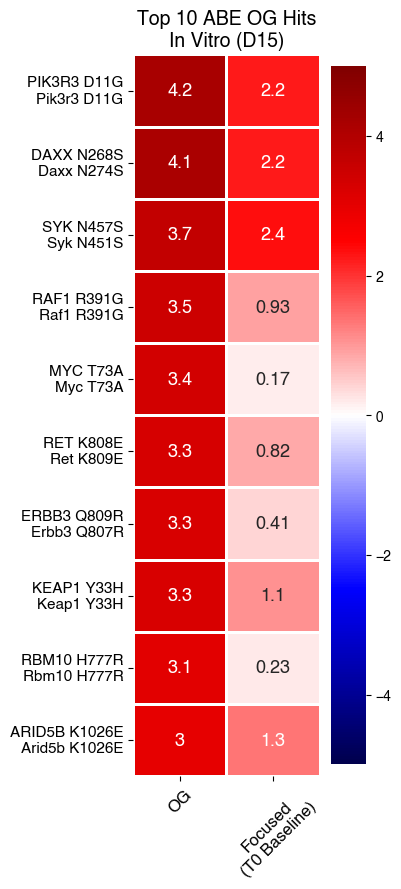

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


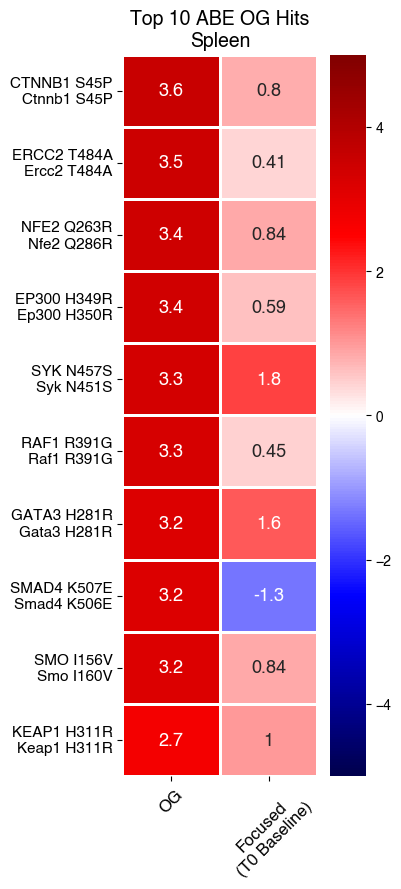

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


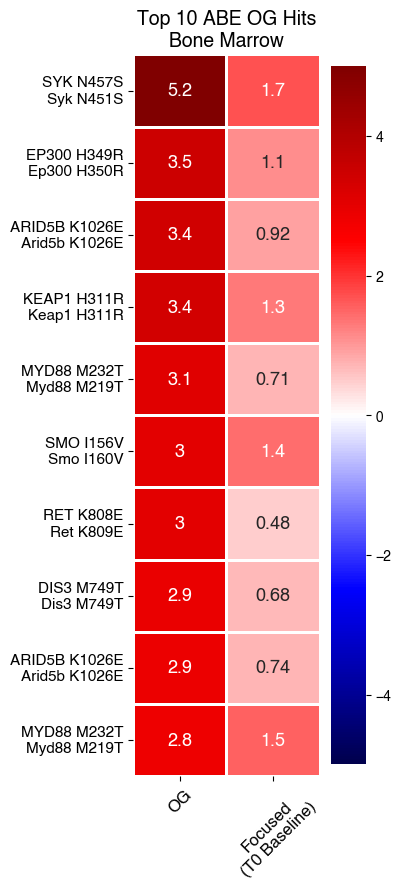

In [ ]:
min_edit           = 10
FDR_cutoff         = 0.1
LFC_cutoff         = 1.0
min_sensor_og      = 10
min_sensor_focused = 100

ABE_OG  = dfs['ABE_OG']
ABE_EPO = dfs['ABE_EPO_T0']

cond_list   = ['d15', 'spleen', 'bm']
cond_labels = {'d15': 'In Vitro (D15)', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}

for cond in cond_list:
    fdr_col    = f'FDR_{cond}_fishers'
    lfc_col    = f'LFC_median_{cond}'
    z_col      = f'z_score_median_{cond}'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    # filter OG hits
    og = ABE_OG[ABE_OG['classification'] == 'targeting guide'].copy()
    if sensor_col in og.columns:
        og = og[og[sensor_col] >= min_sensor_og]
    og = og[og['Input_median'] >= 2]
    og = og[
        (og[edit_col]  >= min_edit) &
        (og[fdr_col]   <= FDR_cutoff) &
        (og[lfc_col].abs() >= LFC_cutoff)
    ].copy()

    og = og.sort_values(by=z_col, ascending=False).reset_index(drop=True)
    top = og.iloc[:10].copy()

    # get focused z-score for same guides
    epo = ABE_EPO[['gRNA_id', z_col]].rename(columns={z_col: 'z_focused'})
    top = pd.merge(top[['gRNA_id', z_col, 'gene_name_h', 'HGVSp_h', 'Gene', 'HGVSp_m']], epo, on='gRNA_id', how='left')
    top = top.rename(columns={z_col: 'z_og'})

    # y-axis labels
    labels = []
    for _, row in top.iterrows():
        hgvs_h = row['HGVSp_h'] if isinstance(row['HGVSp_h'], str) else 'Non-coding'
        labels.append(f"{row['gene_name_h']} {hgvs_h}\n{row['Gene']} {row['HGVSp_m']}")

    fig, ax = plt.subplots(figsize=(4, 9))
    g = sns.heatmap(
        top[['z_og', 'z_focused']],
        cmap='seismic', annot=True, annot_kws={'size': 13},
        linewidth=1, edgecolor='white',
        vmin=-5, vmax=5, ax=ax
    )
    g.set_yticklabels(labels, rotation=0, fontsize=11)
    g.set_xticklabels(['OG', 'Focused\n(T0 Baseline)'], rotation=45, fontsize=12)
    ax.set_title(f'Top 10 ABE OG Hits\n{cond_labels[cond]}', fontsize=14)
    fig.tight_layout()
    plt.savefig(f'figure3c_top10_OG_{cond}.pdf', bbox_inches='tight')
    plt.show()


## 3d

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


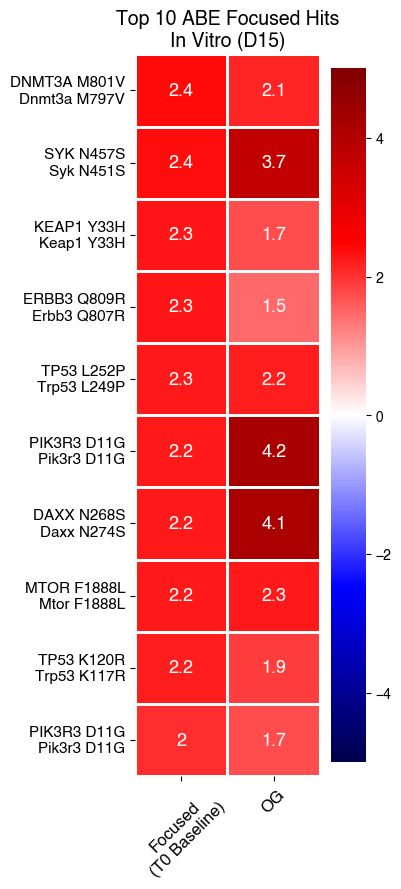

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


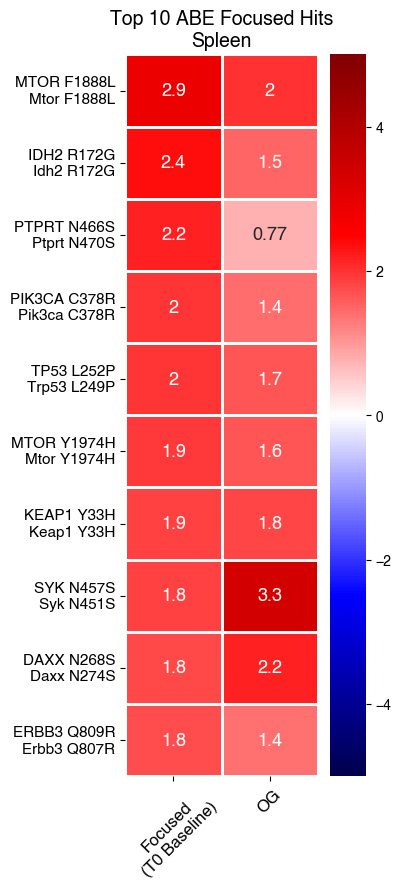

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


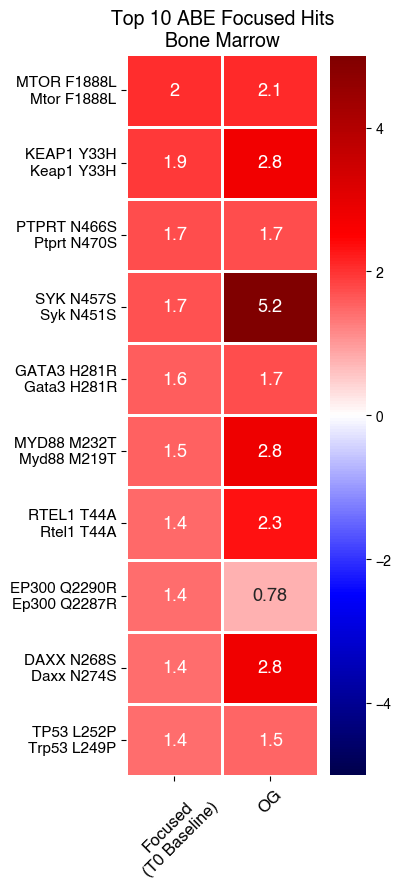

In [ ]:
for cond in cond_list:
    fdr_col    = f'FDR_{cond}_fishers'
    lfc_col    = f'LFC_median_{cond}'
    z_col      = f'z_score_median_{cond}'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    # filter Focused hits
    epo = ABE_EPO[ABE_EPO['classification'] == 'targeting guide'].copy()
    if sensor_col in epo.columns:
        epo = epo[epo[sensor_col] >= min_sensor_focused]
    epo = epo[epo['Input_median'] >= 2]
    epo = epo[
        (epo[edit_col]  >= min_edit) &
        (epo[fdr_col]   <= FDR_cutoff) &
        (epo[lfc_col].abs() >= LFC_cutoff)
    ].copy()
    epo = epo.sort_values(by=z_col, ascending=False).reset_index(drop=True)
    top = epo.iloc[:10].copy()

    # get OG z-score for same guides
    og = ABE_OG[['gRNA_id', z_col]].rename(columns={z_col: 'z_og'})
    top = pd.merge(top[['gRNA_id', z_col, 'gene_name_h', 'HGVSp_h', 'Gene', 'HGVSp_m']], og, on='gRNA_id', how='left')
    top = top.rename(columns={z_col: 'z_focused'})

    # y-axis labels
    labels = []
    for _, row in top.iterrows():
        hgvs_h = row['HGVSp_h'] if isinstance(row['HGVSp_h'], str) else 'Non-coding'
        labels.append(f"{row['gene_name_h']} {hgvs_h}\n{row['Gene']} {row['HGVSp_m']}")

    fig, ax = plt.subplots(figsize=(4, 9))
    g = sns.heatmap(
        top[['z_focused', 'z_og']],
        cmap='seismic', annot=True, annot_kws={'size': 13},
        linewidth=1, edgecolor='white',
        vmin=-5, vmax=5, ax=ax
    )
    g.set_yticklabels(labels, rotation=0, fontsize=11)
    g.set_xticklabels(['Focused\n(T0 Baseline)', 'OG'], rotation=45, fontsize=12)
    ax.set_title(f'Top 10 ABE Focused Hits\n{cond_labels[cond]}', fontsize=14)
    fig.tight_layout()
    plt.savefig(f'figure3d_top10_Focused_{cond}.pdf', bbox_inches='tight')
    plt.show()
